In [1]:
%load_ext autoreload
%autoreload 2
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from mne.time_frequency import tfr_morlet
from mne.time_frequency.tfr import morlet
from mne import combine_evoked
import seaborn as sns
from mne.decoding import Scaler
from sklearn.utils.class_weight import compute_sample_weight

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
paradigm = P300(tmin=-3.2, tmax=4, resample=None, fmax=None, fmin=0.1)
dataset = BNCI2014008()

In [3]:
subject, session, run = 1, "session_0", "run_0"
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Not setting metadata
4200 matching events found
No baseline correction applied
0 bad epochs dropped


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,-3.199 – 4.000 sec
Baseline,off


In [4]:
#_=epochs.plot_psd()

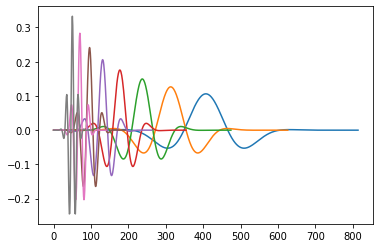

In [5]:
n_freqs=8
sfreq=32
freqs= np.geomspace(1, 16, n_freqs)
n_cycles = np.linspace(2, 4, n_freqs)
wavelets = morlet(epochs.info['sfreq'],
                  freqs, n_cycles, zero_mean=True)
for i in range(n_freqs):
    plt.plot(np.real(wavelets[i]))

In [6]:
epochs = tfr_morlet(epochs, freqs, n_cycles, return_itc=False, average=False,
                    output='complex', verbose=True, n_jobs=12, decim=int(epochs.info['sfreq']//sfreq))
#epochs.data = np.abs(epochs.data).astype(np.float64)
#epochs.apply_baseline((None,None), mode='zlogratio',verbose=True)
epochs.data -= np.average(epochs.data, weights=compute_sample_weight('balanced', labels), axis=0)
epochs.data /= np.std(epochs.data, axis=0)
epochs.crop(0, 1)
epochs

[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   3 out of   8 | elapsed:    9.9s remaining:   16.5s
[Parallel(n_jobs=12)]: Done   5 out of   8 | elapsed:   11.6s remaining:    7.0s
[Parallel(n_jobs=12)]: Done   8 out of   8 | elapsed:   13.1s finished


Not setting metadata


<EpochsTFR | time : [-0.011719, 0.988281], freq : [1.000000, 16.000000], epochs : 4200, channels : 8, ~135.4 MB>

No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied


/tmp/ipykernel_60957/4006895701.py:7: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_60957/4006895701.py:12: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_60957/4006895701.py:17: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_60957/4006895701.py:22: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


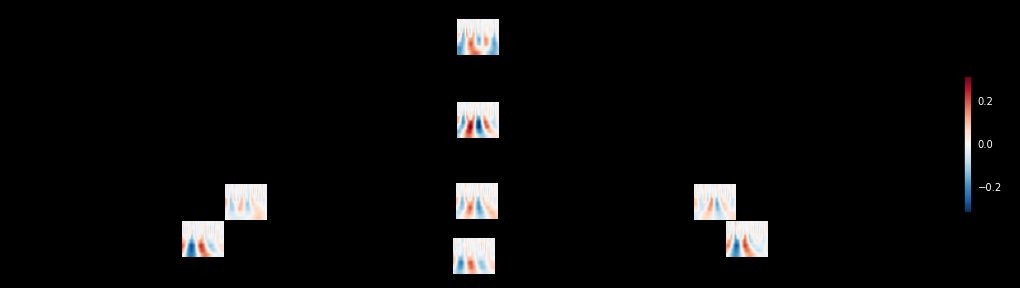

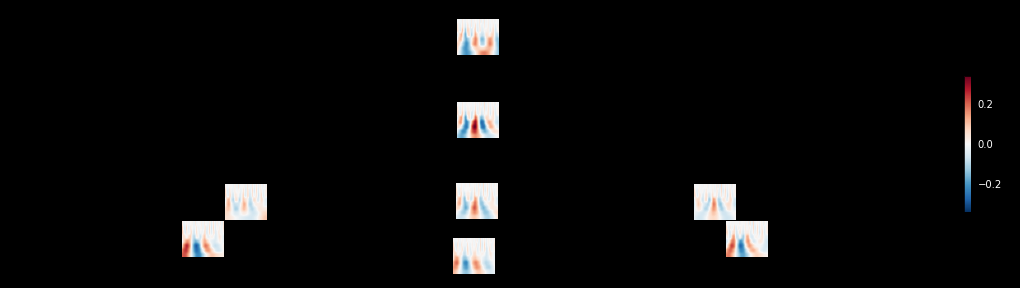

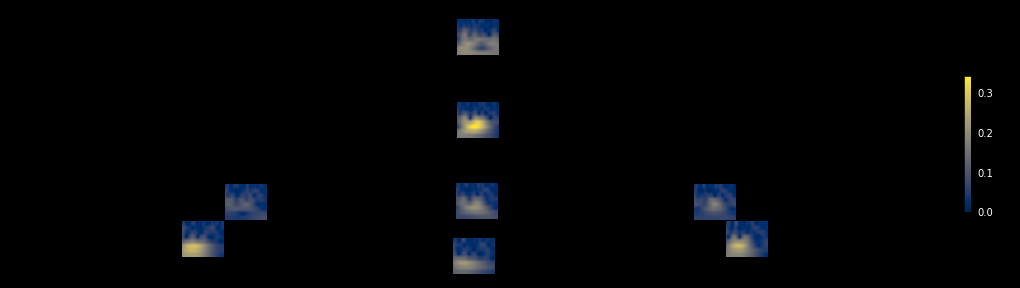

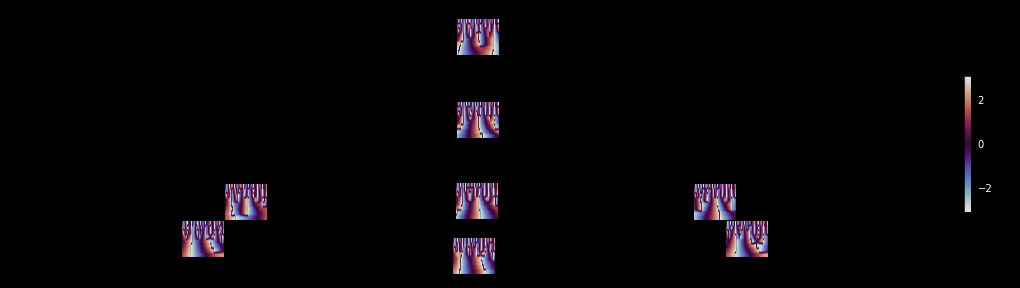

In [7]:
class_names = np.unique(labels)
contrast = epochs[class_names[1]].average() - epochs[class_names[0]].average()
contrast_r = contrast.copy()
contrast_r.data = np.real(contrast_r.data)
fig = contrast_r.plot_topo(show=False, cmap='RdBu_r')
fig.set_figwidth(16)
fig.show()
contrast_i = contrast.copy()
contrast_i.data = np.imag(contrast_i.data)
fig = contrast_i.plot_topo(show=False, cmap='RdBu_r')
fig.set_figwidth(16)
fig.show()
contrast_m = contrast.copy()
contrast_m.data = np.abs(contrast_m.data)
fig = contrast_m.plot_topo(show=False, cmap='cividis', vmin=0)
fig.set_figwidth(16)
fig.show()
contrast_p = contrast.copy()
contrast_p.data = np.angle(contrast_p.data)
fig = contrast_p.plot_topo(show=False, cmap='twilight')
fig.set_figwidth(16)
fig.show()

In [8]:
X = epochs.data
y = labels

In [ ]:
hoda = HODA(max_iter=64, rank=(8,8,32), tol=0, initialize ='random', verbose=True,
            toeplitz=2, taper=None, shrinkage='oas', solver='eig')
hoda.fit(X,y)

Iteration 0  updates: [ 6.95575501  6.4879701  27.1256399 ]  objective: 0.05627869612870598
Iteration 1  updates: [3.74888288 4.10848135 7.10759931]  objective: 0.05627868180473269
Iteration 2  updates: [3.65146106e-04 7.00719584e-04 6.42217466e-06]  objective: 0.056278681810278175
Iteration 3  updates: [2.15605643e-09 1.20156195e-08 9.50908989e-06]  objective: 0.056278681812234804
Iteration 4  updates: [4.66170313e-09 8.84025949e-09 1.57691585e-05]  objective: 0.05627868179590881
Iteration 5  updates: [6.14378049e-09 1.15566524e-08 2.34424842e-05]  objective: 0.05627868179302386
Iteration 6  updates: [8.23666466e-09 6.97504206e-08 2.45497405e-05]  objective: 0.05627868182831418
Iteration 7  updates: [1.88094580e-08 8.05089082e-08 1.83694281e-05]  objective: 0.05627868180156824
Iteration 8  updates: [2.81635947e-09 1.84451965e-08 2.38288215e-05]  objective: 0.05627868180479498
Iteration 9  updates: [7.78070515e-09 1.32839894e-08 2.30224448e-05]  objective: 0.05627868179101049
Iteration

In [ ]:
plt.semilogy(hoda.updates_[:,:hoda.iter_].T)
plt.show()

In [ ]:
plt.plot(hoda.objective_)
plt.show()

In [ ]:
"""
print(hoda.rank_)
for k in range(3):
    Uk = hoda.projs_[k]
    vmax = np.max(np.abs(Uk))
    fig, axs = plt.subplots(1,Uk.shape[1], figsize=(16,6))
    if Uk.shape[1]==1:
        axs = [axs]
    for i in range(Uk.shape[1]):
        if k==0:
            plot_topomap(Uk[:,i], epochs.info, axes=axs[i], show=False)        
            pass
        elif k == 2 or k==1:
            for i in range(Uk.shape[1]):
                axs[i].plot(Uk[:,i])

        else:
            sns.heatmap(Uk, cmap='RdBu_r', vmin=-vmax, vmax=vmax, ax=axs[i])
    fig.show()
"""

In [ ]:
for k in range(3):
    sns.heatmap(np.real(hoda.scatter_w_[k]), cmap='BrBG', vmin=-np.max(np.abs(np.real(hoda.scatter_w_[k]))), vmax=np.max(np.abs(np.real(hoda.scatter_w_[k]))))
    plt.show()
    sns.heatmap(np.imag(hoda.scatter_w_[k]), cmap='BrBG', vmin=-np.max(np.abs(np.imag(hoda.scatter_w_[k]))), vmax=np.max(np.abs(np.imag(hoda.scatter_w_[k]))))
    plt.show()


In [ ]:
for k in range(3):
    sns.heatmap(np.real(hoda.scatter_b_[k]), cmap='BrBG', vmin=-np.max(np.abs(np.real(hoda.scatter_b_[k]))), vmax=np.max(np.abs(np.real(hoda.scatter_b_[k]))))
    plt.show()
    sns.heatmap(np.imag(hoda.scatter_b_[k]), cmap='BrBG', vmin=-np.max(np.abs(np.imag(hoda.scatter_b_[k]))), vmax=np.max(np.abs(np.imag(hoda.scatter_b_[k]))))
    plt.show()


In [ ]:
"""
print(hoda.rank_)
for k in range(3):
    patterns = (hoda.projs_[k].T@hoda.scatter_w_[k]).T
    vmax = np.max(np.abs(patterns))
    fig, axs = plt.subplots(1,patterns.shape[1], figsize=(16,6), sharex=True, sharey=True)
    if patterns.shape[1]==1:
        axs = [axs]
    for i in range(patterns.shape[1]):
        if k==0:
            plot_topomap(patterns[:,i], epochs.info, axes=axs[i], show=False)        
            pass
        elif k == 2 or k==1:
            for i in range(patterns.shape[1]):
                axs[i].plot(patterns[:,i])
        else:
            sns.heatmap(patterns, cmap='RdBu_r', vmin=-vmax, vmax=vmax, ax=axs[i])
    fig.show()
"""

In [ ]:
Xt = hoda.transform(X)

In [ ]:
pca = PCA(n_components=2)
X_pc = pca.fit_transform(Xt)
plt.scatter(X_pc[:,0], X_pc[:,1],c=labels=='Target')

In [ ]:
lda = LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
lda.fit(Xt,y)

In [ ]:
roc_auc_score(y, lda.predict_proba(Xt)[:,1])